In [11]:
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans

mnist = fetch_openml('mnist_784', as_frame=False)
X=mnist.data
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [5]:
y = mnist.target
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [12]:
kmeans = KMeans(n_clusters=10)
kmeans.fit(X)
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

[3 0 7 ... 1 2 6]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


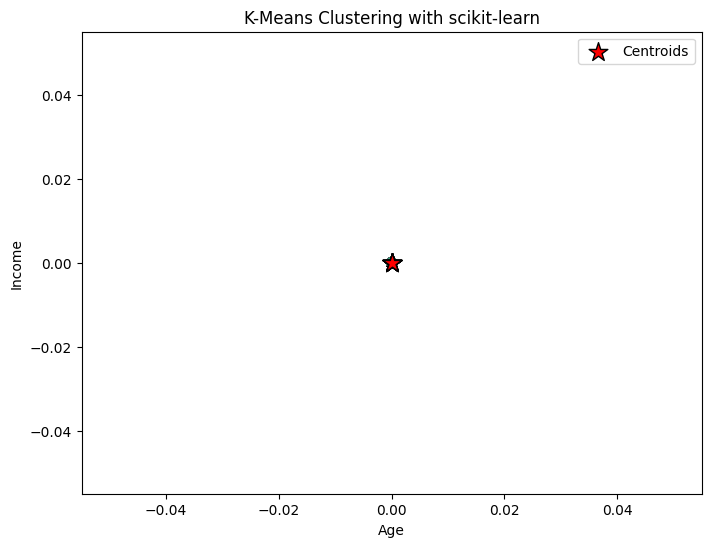

In [10]:
import matplotlib.pyplot as plt
y_kmeans = kmeans.labels_
print(y_kmeans)
centers = kmeans.cluster_centers_
print(centers)
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='*', s=200, label='Centroids', edgecolor='k')
plt.title('K-Means Clustering with scikit-learn')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.show()

In [ ]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
import numpy as np

# Load the MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X / 255.  # Normalize pixel values
y = y.astype(int)

# Split data into labeled and unlabeled sets
rng = np.random.RandomState(42)
labeled_indices = rng.choice(len(y), size=1000, replace=False) # Use 1000 labeled samples
unlabeled_indices = np.setdiff1d(np.arange(len(y)), labeled_indices)

X_labeled = X.iloc[labeled_indices]
y_labeled = y.iloc[labeled_indices]

X_unlabeled = X.iloc[unlabeled_indices]
y_unlabeled = y.iloc[unlabeled_indices]

# Assign a special value to unlabeled data
y_unlabeled_semi = np.full(len(y_unlabeled), -1)

# Combine labeled and unlabeled data for training
X_train_semi = np.concatenate((X_labeled, X_unlabeled))
y_train_semi = np.concatenate((y_labeled, y_unlabeled_semi))

# Use SelfTrainingClassifier with a base estimator
base_classifier = RandomForestClassifier(n_estimators=100)
stc = SelfTrainingClassifier(base_classifier)

# Fit the model
stc.fit(X_train_semi, y_train_semi)

# Evaluate on a test set (you'd normally split the original data into train/test first)
# For simplicity, we'll just check against the original labels
print(f"Accuracy with pseudo-labeling: {stc.score(X_unlabeled, y_unlabeled)}")